# Versión 2.5 — Panel de señales configurable multimercado

## Diferencias respecto a la versión 2.4

- La V2.4 gestiona una posición real configurada manualmente. La V2.5.1 no consulta la cuenta ni necesita saber qué operaciones ejecutaste.
- La V2.5.1 reconstruye tres estrategias virtuales independientes: LONG RSI+Bollinger, SHORT RSI y SHORT Ruptura. Una entrada LONG nunca bloquea una entrada SHORT, y los dos sistemas SHORT tampoco se bloquean entre sí.
- Cada sistema mantiene como máximo una operación virtual abierta: mientras esa operación siga abierta no duplica nuevas entradas del mismo sistema, pero los otros sistemas continúan evaluándose.
- Cada estrategia solo genera SALIR si antes generó su propia entrada virtual. Cada entrada queda enlazada con su salida, sus fechas y los valores que activaron ambas señales.
- Las operaciones y marcas relacionadas con los últimos 30 días permanecen en el informe y en los gráficos.
- El precio virtual de entrada es el cierre que dispara la señal; las indicaciones siguen siendo informativas para la próxima apertura.

In [9]:
# ========================= CONFIGURACIÓN V2.5.1 =========================
ACTIVOS = [
    #'META',
    #'SHOP',
    'AAPL',
    # 'NVDA',
    'MSFT',
    # 'AMZN',
]

# None/'HOY' analiza el último cierre disponible.
FECHA_FIN = None
# FECHA_FIN = '2026-08-26'
AJUSTAR_DIVIDENDOS = True

# LONG: todos los criterios descomentados deben cumplirse a la vez (AND).
# Comenta o descomenta una línea para quitar o añadir ese criterio.
CRITERIOS_LONG = [
    'RSI_SOBREVENTA',
    'BOLLINGER_INFERIOR',
]
# La salida LONG conserva la V2.4: basta un criterio activo (OR).
CRITERIOS_SALIDA_LONG = [
    'RSI_RECUPERADO',
    'BOLLINGER_MEDIA',
    'STOP_PROTECCION',
]

# SHORT: basta con que se cumpla uno de los sistemas activos (OR).
# Se conserva la V2.4: RSI > 70, o RUPTURA de precio + volumen.
SISTEMAS_SHORT_ACTIVOS = [
    'RSI',
    'RUPTURA',
]

# Dentro de cada sistema SHORT, los criterios activos se combinan con AND.
CRITERIOS_SHORT_RSI = [
    'RSI_SOBRECOMPRA',
]
CRITERIOS_SHORT_RUPTURA = [
    'RUPTURA_MINIMO',
    'VOLUMEN_RUPTURA',
]

# Salidas SHORT por sistema. Dentro de cada lista basta una condición (OR).
CRITERIOS_SALIDA_SHORT_RSI = [
    'RSI_NORMALIZADO',
    'STOP_PROTECCION',
]
CRITERIOS_SALIDA_SHORT_RUPTURA = [
    'DOS_CIERRES_EMA',
    'RSI_FIN_RUPTURA',
    'MAX_SESIONES',
    'TRAILING_ATR',
]

# Periodos y umbrales editables. Los valores iniciales reproducen V2.4.
RSI_PERIODO = 14
UMBRAL_RSI_LONG = 30
BOLLINGER_PERIODO = 20
BOLLINGER_DESVIACIONES = 2.0
UMBRAL_SALIDA_LONG_RSI = 65
UMBRAL_RSI_SHORT = 70
UMBRAL_SALIDA_SHORT_RSI = 50
UMBRAL_FIN_RUPTURA_RSI = 55
PERIODO_RUPTURA = 20
MULTIPLICADOR_VOLUMEN = 1.00
EMA_SHORT_PERIODO = 10
ATR_PERIODO = 14
STOP_LONG = 0.07
STOP_SHORT = 0.07
RUPTURA_ATR = 2.0
RUPTURA_MAX_SESIONES = 20
VENTANA_SENALES_DIAS = 30
# ======================================================================

## Calendario dinámico de eventos

Mantiene los bloques verticales por valor de la V2.4 y comparte las fechas de resultados con los gráficos.

In [10]:
from calendario_eventos_v2_5_1 import generar_calendario_eventos

EVENTOS_CALENDARIO_MANUALES = globals().get('EVENTOS_CALENDARIO_MANUALES', {})
_calendario = generar_calendario_eventos(
    ACTIVOS, eventos_manuales=EVENTOS_CALENDARIO_MANUALES, mostrar=True
)
FECHAS_RESULTADOS_GRAFICOS = _calendario['FECHAS_RESULTADOS_GRAFICOS']
DATOS_ALERTA_RESULTADOS = _calendario['DATOS_ALERTA_RESULTADOS']
FILAS_CALENDARIO_EVENTOS = _calendario['FILAS_CALENDARIO_EVENTOS']

Fecha prevista,Tipo,Evento próximo,Precisión,Fuente
29/10/2026,Presentación de resultados,Próxima presentación de resultados.,Aproximada,Fuente
Fecha del evento,Tipo,Resumen del evento,Impacto bursátil,Fuentes
30/07/2026,Presentación de resultados,Evento: Presentación de resultados trimestrales.Reuters: Apple decepciona con el pronóstico perseguido por las luchas de la cadena de suministroCNBC: Los traders de 'dinero rápido' reaccionan a las ganancias de AppleWSJ: Apple espera un crecimiento más lento después de que el auge de la IA eleve los costes,↓ -7.35 %,Reuters · CNBC · WSJ
25/06/2026,Movimiento diario entre el 5 % y el 7 %,AP News: Wall Street se desplaza a un final mixto después de que Micron se dispare y la manzana caigaCNBC: Las acciones de Apple se ven afectadas por las subidas de precios de los Mac y iPad más grandes. Por qué puede capear la tormentaWSJ: Las acciones estadounidenses se mezclan con las subidas de micras y las caídas de Apple,↓ -6.12 %,AP News · CNBC · WSJ
30/04/2026,Presentación de resultados,"Evento: Presentación de resultados trimestrales.AP News: Apple supera las estimaciones de ganancias con el impulso continuo del iPhoneCNBC: La guía de ingresos de Apple supera las estimaciones sobre la creciente demanda de iPhone y MacWSJ: Apple ve un aumento en las ventas, impulsado por el iPhone 17 y China",↑ +3.69 %,AP News · CNBC · WSJ
Fecha prevista,Tipo,Evento próximo,Precisión,Fuente
28/10/2026,Presentación de resultados,Próxima presentación de resultados.,Aproximada,Fuente
Fecha del evento,Tipo,Resumen del evento,Impacto bursátil,Fuentes
29/07/2026,Presentación de resultados,"Evento: Presentación de resultados trimestrales.AP News: Microsoft supera las expectativas de Wall Street con $ 90 mil millones en ingresosCNBC: Microsoft aumenta un 8% a medida que impulsa los planes de gasto de capital, citando la demandaFortune: La nube de Microsoft acaba de alcanzar un nuevo hito: Azure supera los $ 100 mil millones en ingresos anuales",↑ +15.51 %,AP News · CNBC · Fortune
26/06/2026,Movimiento diario entre el 5 % y el 7 %,"Yahoo Finance: Las acciones de Microsoft alcanzan el mínimo de un año en medio de preocupaciones sobre el gasto enCNBC: Microsoft eleva el precio de las consolas Xbox debido al alza de los costes de los componentesMarketWatch: Las acciones de Microsoft están sufriendo una caída histórica en junio, ya que los inversores se resisten a un fuerte gasto",↑ +5.71 %,"Yahoo Finance · <a href=""https://news.google.com/rss/articles/CBMiqgFBVV95cUxPMFZmX2ZDRTFuMFlkcFBfc3A2Y0tiSTVyWTVfN2JEeVNZMVVFNWVxUGpzZFNtVVJmRlBSUTJxcWMxcW9nbmJJZ1NNd2Z6bUVDdFBtZ2E5N0REdFVsN0YxNE84QTZBX0hFRUN4bmZiVy1RU3NGXzJlRTB4UXUxOFdhQWNEYXYxQUIyQml1RDFUcWZaQ0JUZGt1bFQ3UmFVYWNQV1RWT1pOYXhoUdIBrwFBVV95cUxNd0lTbVFPM0drUkZmVGY1V0JCRFRqajQ4NkJqLWVzSEZaNFliMGVOLTVGakhnVjVpNV90T0ZEN1oybFluY1Etakd4VzZmRkQ1a19hZWxHZnNXYlZhRHo1VnZ5RTZiUGJqeU10RWV3Y1NJMVZpQ3NpZkFFdXRtTVFkSFZuWllGSFRpYnYxcDZhbnVVZGpUa09JeGdDZWpYSldlNHhSY2tERzMySW9XaWFR?oc=5"" target=""_blank"" rel=""noopener noreferrer"">CNBC · MarketWatch"


Informe V2.5.1 guardado en: C:\Users\carlos.jimenez\Scripts_Bolsa_GitHub\salida_operativa\calendario_resultados\informe_resultados_v2_5_1.html


## Panel de disparadores LONG y SHORT

Cada valor muestra primero LONG y justo debajo SHORT. Todos los parámetros aparecen siempre con sus valores actuales. Las entradas se activan en verde con **ENTRAR** y las salidas en rojo con **SALIR**. Debajo figura el historial de activaciones de 30 días, que también se marca en los gráficos.

PANEL DE SEÑALES V2.5.1 — cierre 2026-08-28



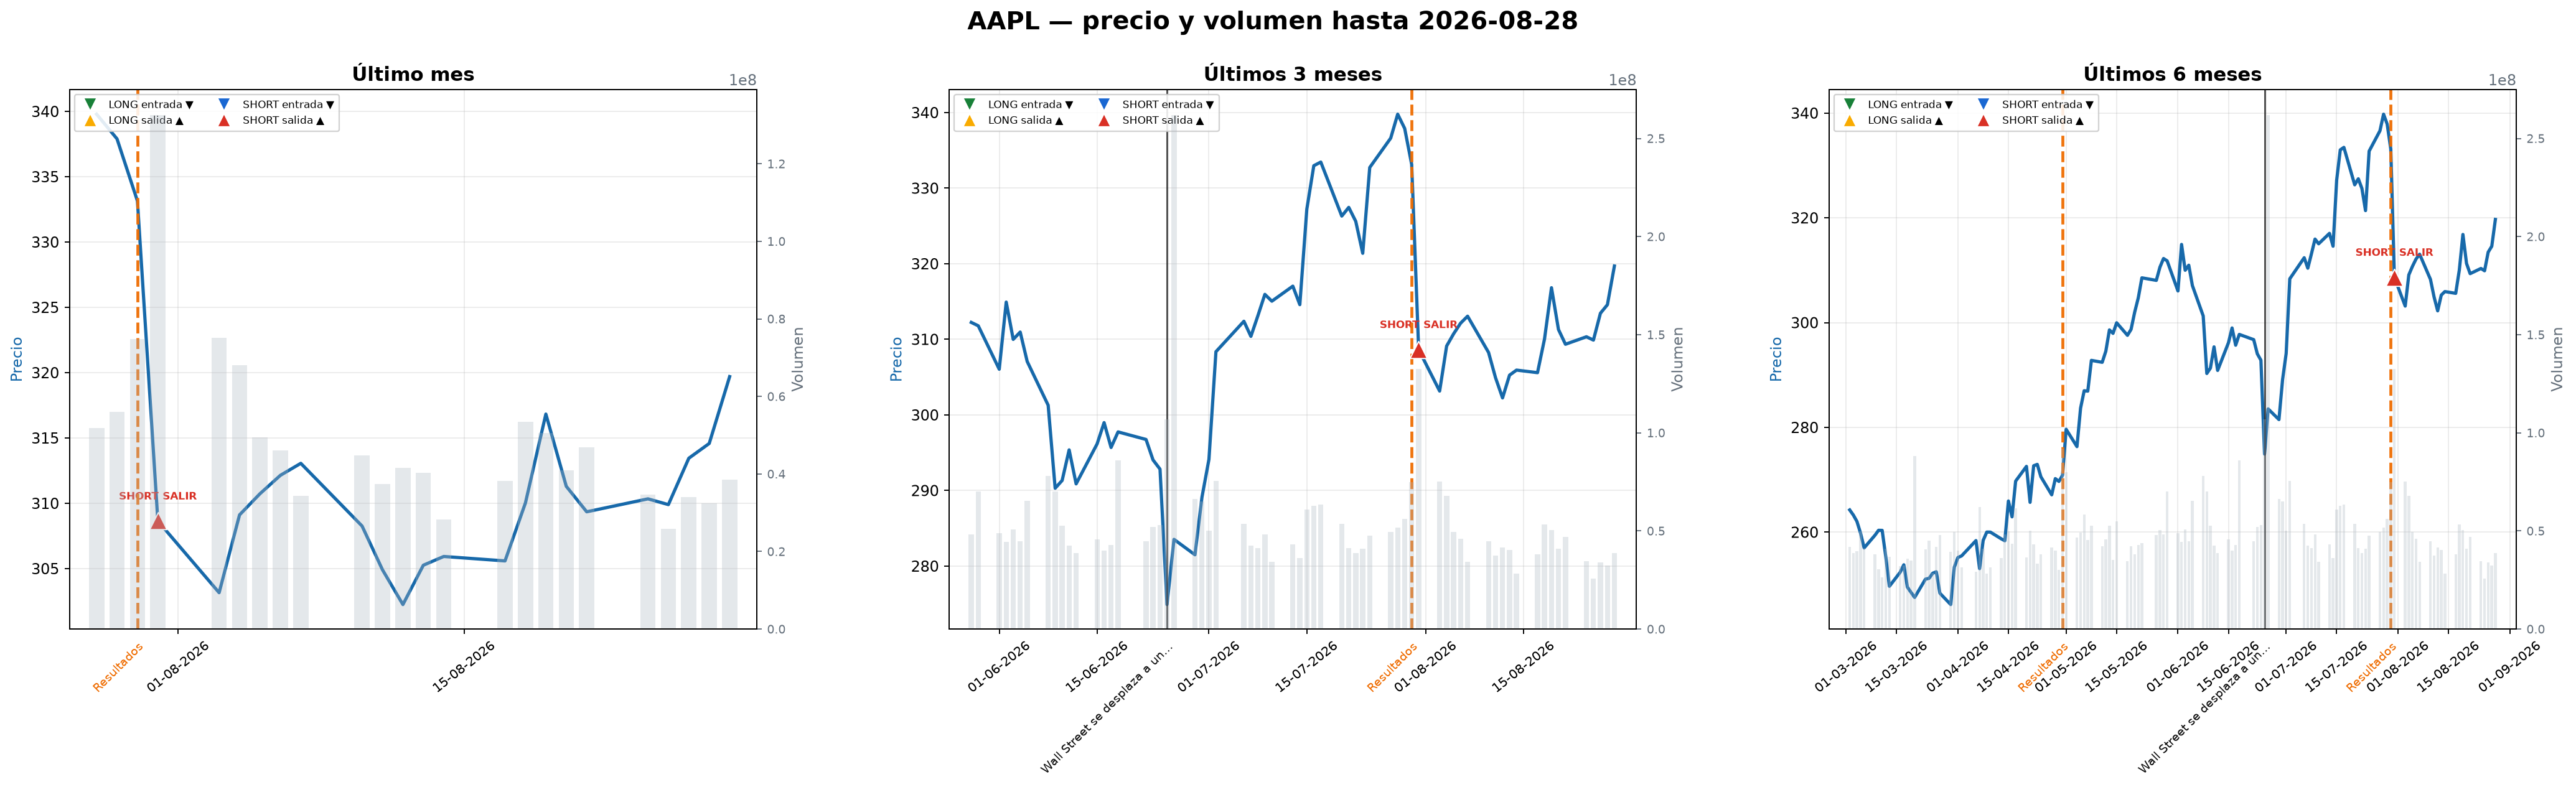

Lado,Sistema,Entrada virtual,Valores de entrada,Salida virtual,Valores de salida
SHORT,RSI,▼ ENTRAR 15/07/2026 a 327.22,✓ RSI 14 = 70.2 > 70,▲ SALIR 31/07/2026 a 308.64Activó: RSI normalizado,✓ RSI 14 = 45.1 < 50; ✗ cierre 308.64 ≥ stop 350.12



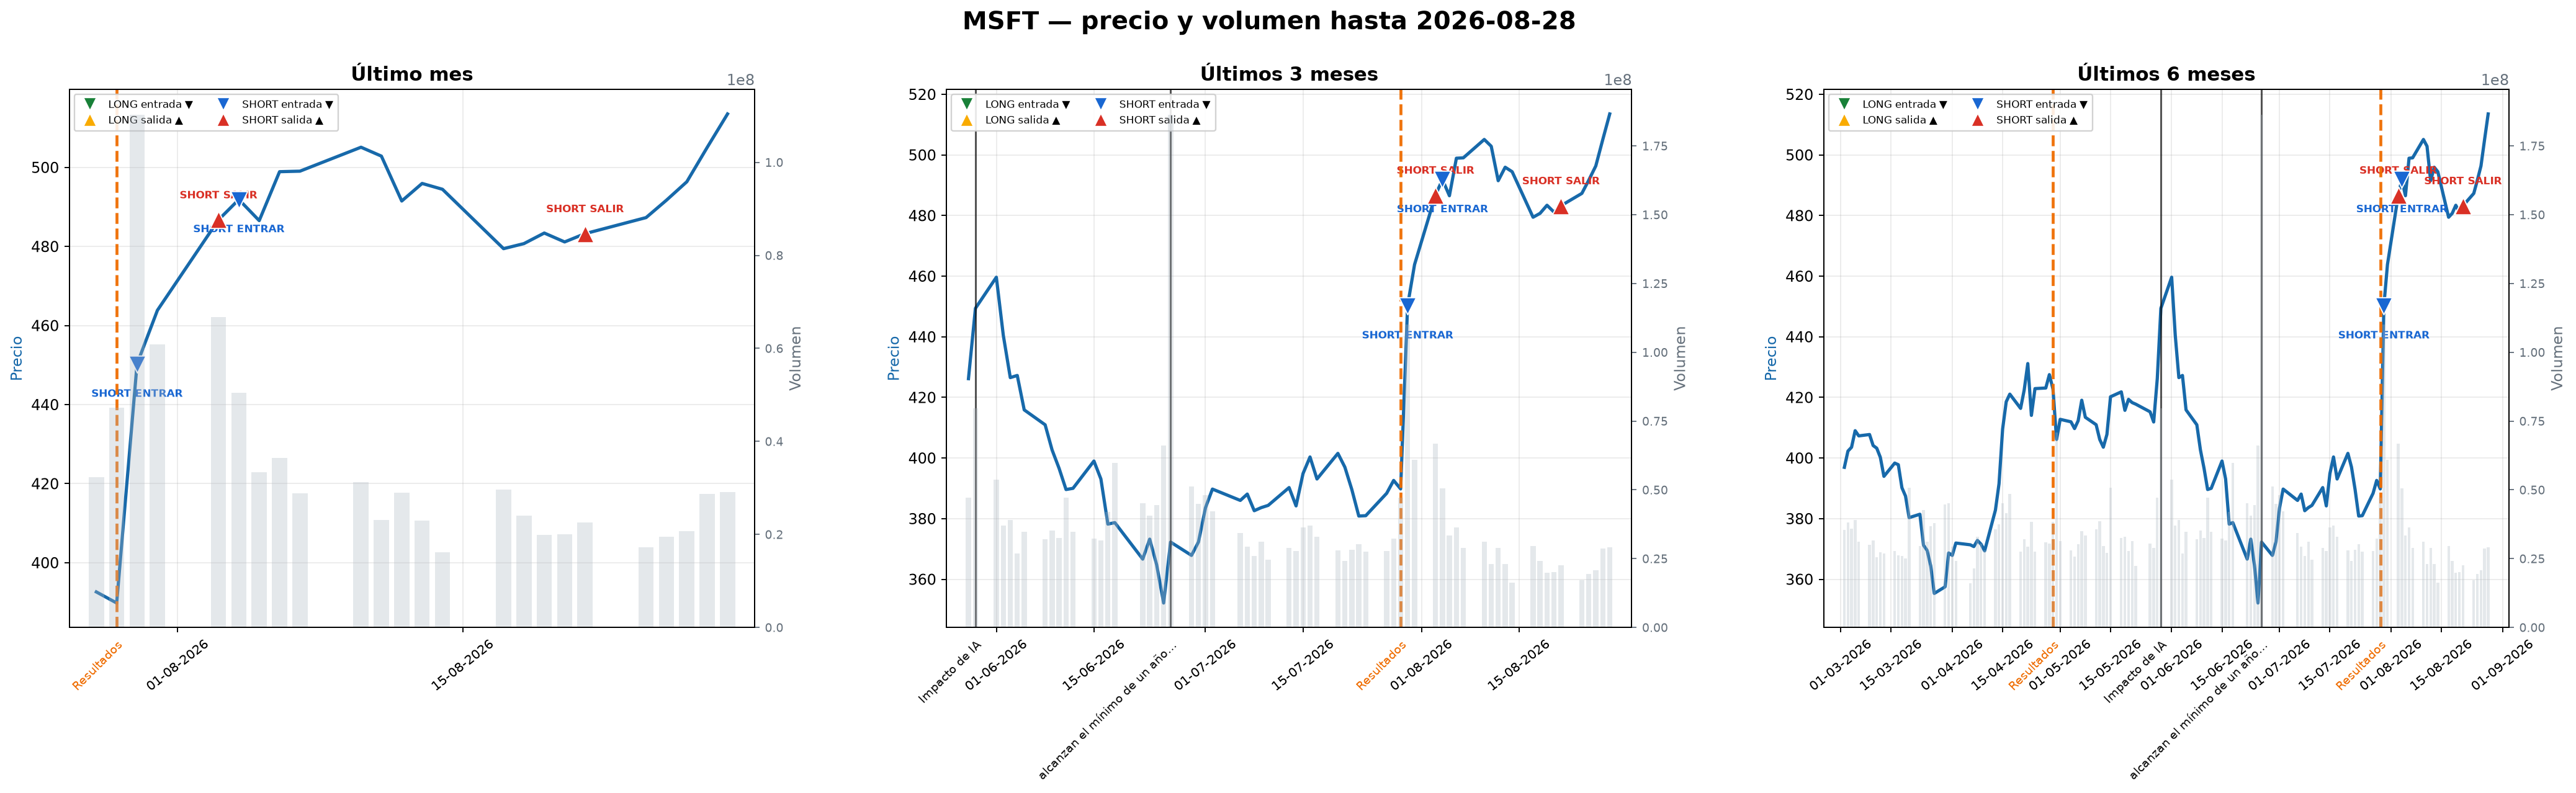

Lado,Sistema,Entrada virtual,Valores de entrada,Salida virtual,Valores de salida
SHORT,RSI,▼ ENTRAR 04/08/2026 a 491.88,✓ RSI 14 = 80.6 > 70,▲ SALIR 21/08/2026 a 483.24Activó: RSI normalizado,✓ RSI 14 = 47.6 < 50; ✗ cierre 483.24 ≥ stop 526.32
SHORT,RSI,▼ ENTRAR 30/07/2026 a 450.25,✓ RSI 14 = 73.6 > 70,▲ SALIR 03/08/2026 a 486.73Activó: Stop,✗ RSI 14 = 81.3 < 50; ✓ cierre 486.73 ≥ stop 481.77


Resumen V2.5.1 guardado en: C:\Users\carlos.jimenez\Scripts_Bolsa_GitHub\salida_operativa\resumen_senales_v2_5_1.html


In [11]:
import importlib
import panel_senales_v2_5_1
importlib.reload(panel_senales_v2_5_1)
from panel_senales_v2_5_1 import generar_panel_senales

resultado_v2_5_1 = generar_panel_senales(
    ACTIVOS,
    fecha_fin=FECHA_FIN,
    ajustar_dividendos=AJUSTAR_DIVIDENDOS,
    criterios_long=CRITERIOS_LONG,
    criterios_salida_long=CRITERIOS_SALIDA_LONG,
    sistemas_short=SISTEMAS_SHORT_ACTIVOS,
    criterios_short_rsi=CRITERIOS_SHORT_RSI,
    criterios_short_ruptura=CRITERIOS_SHORT_RUPTURA,
    criterios_salida_short_rsi=CRITERIOS_SALIDA_SHORT_RSI,
    criterios_salida_short_ruptura=CRITERIOS_SALIDA_SHORT_RUPTURA,
    rsi_periodo=RSI_PERIODO,
    umbral_rsi_long=UMBRAL_RSI_LONG,
    bollinger_periodo=BOLLINGER_PERIODO,
    bollinger_desviaciones=BOLLINGER_DESVIACIONES,
    umbral_salida_long_rsi=UMBRAL_SALIDA_LONG_RSI,
    umbral_rsi_short=UMBRAL_RSI_SHORT,
    umbral_salida_short_rsi=UMBRAL_SALIDA_SHORT_RSI,
    umbral_fin_ruptura_rsi=UMBRAL_FIN_RUPTURA_RSI,
    periodo_ruptura=PERIODO_RUPTURA,
    multiplicador_volumen=MULTIPLICADOR_VOLUMEN,
    ema_short_periodo=EMA_SHORT_PERIODO,
    atr_periodo=ATR_PERIODO,
    stop_long=STOP_LONG,
    stop_short=STOP_SHORT,
    ruptura_atr=RUPTURA_ATR,
    ruptura_max_sesiones=RUPTURA_MAX_SESIONES,
    ventana_senales_dias=VENTANA_SENALES_DIAS,
    fechas_resultados=FECHAS_RESULTADOS_GRAFICOS,
    datos_alerta_resultados=DATOS_ALERTA_RESULTADOS,
    filas_calendario_eventos=FILAS_CALENDARIO_EVENTOS,
    mostrar=True,
)
SENALES_V2_5 = resultado_v2_5_1['senales']
HISTORIAL_SENALES_V2_5 = resultado_v2_5_1['historial_senales']
OPERACIONES_VIRTUALES_V2_5 = resultado_v2_5_1['operaciones_virtuales']
ARCHIVO_RESUMEN_V2_5 = resultado_v2_5_1['archivo_html']

## Uso diario

1. Ajusta los criterios activos comentando o descomentando líneas en la configuración.
2. Modifica periodos o umbrales si quieres probar otra variante.
3. Ejecuta todas las celdas después del cierre estadounidense.
4. `ENTRAR` verde abre una operación virtual del sistema correspondiente; `SALIR` rojo solo puede aparecer después de esa entrada.
5. Revisa la tabla para ver cada entrada enlazada con su salida y los valores que activaron ambas.
6. Las marcas del gráfico conservan las entradas y salidas relacionadas con los 30 días anteriores.
7. LONG, SHORT RSI y SHORT Ruptura son independientes de la cuenta real y entre sí.

El notebook no transmite órdenes ni comprueba posiciones, stops, disponibilidad o coste de préstamo para operar en corto.